Loaded graph: KGene.gpickle
Nodes: 2409, edges: 39301
Meta shape (pheno_onehot): (2409, 14)


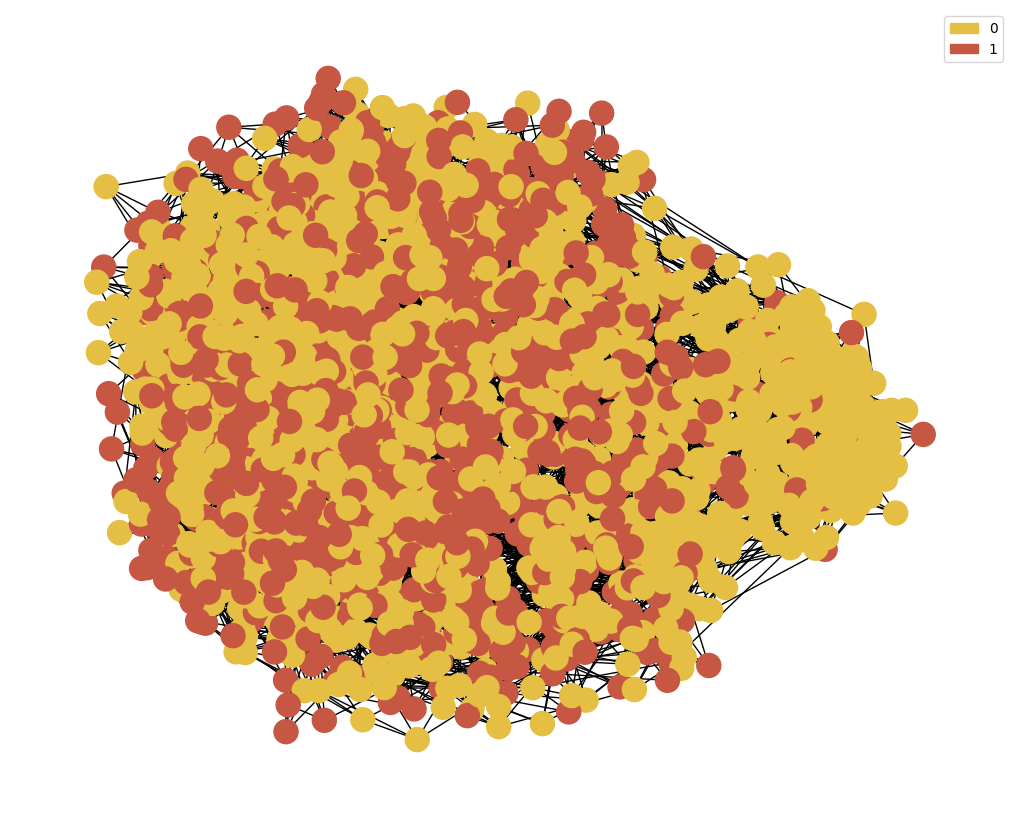

Single-omic PSN: nodes=2409, edges=9511
Nodes missing 'pheno_onehot' after transfer: 0 (OK if 0)
Edge weight stats: count=9511, min=0.0368, max=0.2982, mean=0.1201


/tmp/2827716/ipykernel_1917097/3565834229.py:209: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("tab20", len(cats) if len(cats) > 0 else 1)


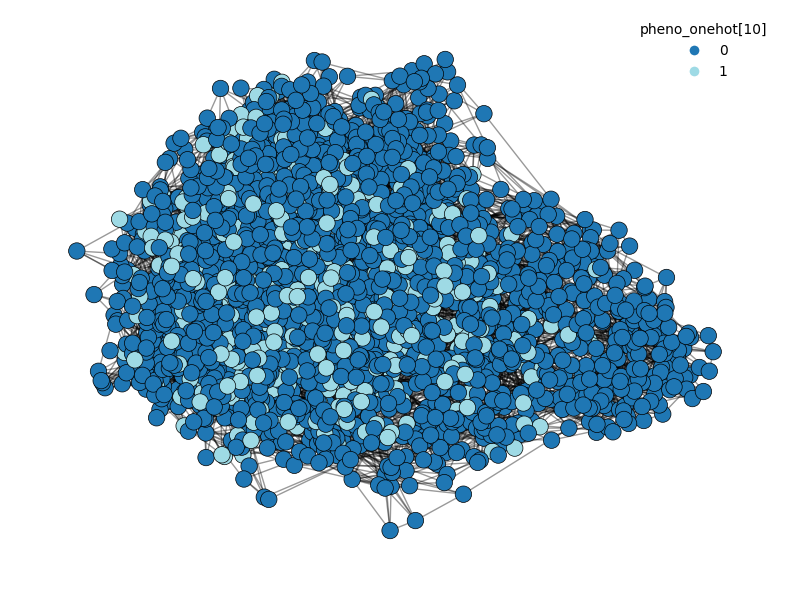

Saved PSN to: /work/gr-fe/bryan/data/YEAST/Networks/KGene_psn.gpickle
Size on disk: 556.5 KiB


In [2]:
# Yeast PSN construction and visualization 
# ------------------------------------------------------------------------------
# This cell:
# - Loads a graph with phenotype one-hot attributes
# - Loads omics matrices and builds a patient similarity network (PSN) via kNN
# - Optionally integrates multiple omics PSNs
# - Normalizes edge weights and transfers node attributes
# - Visualizes the PSN colored by a selected phenotype
# - Saves the PSN as a NetworkX gpickle
#
# If you need packages, uncomment:
# !pip install -q numpy pandas networkx matplotlib scipy

import os
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

# If your utils live outside the current working dir, insert that path so `network_functions` is importable
# Adjust as needed (e.g., "../MAIN/" or a fully-qualified path)
sys.path.insert(0, "./../MAIN/")

# DGL backend (kept from original; safe if unused)
os.environ["DGLBACKEND"] = "pytorch"

from network_functions import (
    fix_node_attrs,
    fix_pheno_onehot_in_graph,
    knn_graph_generation,
    integrate_networks_weighted,
    normalize_edge_weights_symmetric,
    transfer_attributes,
)

# -----------------------------
# Configuration
# -----------------------------
datadir = Path("/work/gr-fe/bryan/data/YEAST")
graphs_dir = datadir / "Networks"
processed_dir = datadir / "02_processed"

GRAPH_PREFIX = "KGene"
g_te_path = graphs_dir / f"{GRAPH_PREFIX}.gpickle"
g_psn_out = graphs_dir / f"{GRAPH_PREFIX}_psn.gpickle"

# Omics to include (the pickle file should be {OMIC}.pkl with key 'expr' inside)
omics = ["EXPR"]  # e.g., ["EXPR"] or ["EXPR", "METH", "CNV"]

# kNN and similarity settings
KNN = 5
SIM_METHOD = "pearson"  # per your original code

# Which phenotype index to use:
# - For kNN supervision (label/series passed to knn_graph_generation)
# - For coloring nodes in the plot
PHENO_IDX_FOR_KNN = 1
PHENO_IDX_FOR_PLOT = 10  # change as needed

# Integration behavior if multiple omics
INTEGRATE_MODE = "union"
MISSING_POLICY = "fill"
FILL_VALUE = 0.0

# Plot settings
SEED = 42
NODE_SIZE = 140
EDGE_ALPHA = 0.4

# -----------------------------
# Load graph and gather phenotype metadata
# -----------------------------
assert g_te_path.exists(), f"Missing graph: {g_te_path}"
with open(g_te_path, "rb") as f:
    g_te = pickle.load(f)

print(f"Loaded graph: {g_te_path.name}")
print(f"Nodes: {g_te.number_of_nodes()}, edges: {g_te.number_of_edges()}")

# Ensure node IDs are strings (to match expression indices)
nodes = set(str(n) for n in g_te.nodes)

# Build a DataFrame of pheno_onehot (assumes attribute exists and is indexable)
meta = pd.DataFrame(nx.get_node_attributes(g_te, "pheno_onehot")).T
if meta.empty:
    raise ValueError("No 'pheno_onehot' node attribute found in g_te.")
print("Meta shape (pheno_onehot):", meta.shape)

# -----------------------------
# Build PSN for one or multiple omics
# -----------------------------
def load_expr(omic_name: str, processed_dir: Path) -> pd.DataFrame:
    """
    Load expression/features matrix from a pickle containing {'expr': DataFrame}.
    Ensures 'ID' is the index and filters to nodes present in the graph.
    """
    pkl_path = processed_dir / f"{omic_name}.pkl"
    if not pkl_path.exists():
        raise FileNotFoundError(f"Expected {pkl_path} for omic={omic_name}")
    with open(pkl_path, "rb") as f:
        payload = pickle.load(f)
    if "expr" not in payload:
        raise KeyError(f"'expr' key not found in {pkl_path}. Keys: {list(payload.keys())}")
    expr = payload["expr"].reset_index()
    if "ID" not in expr.columns:
        raise KeyError(f"'ID' column missing in expr from {pkl_path}")
    expr["ID"] = expr["ID"].astype(str)
    expr = expr.set_index("ID")
    idx_keep = sorted(list(set(expr.index) & nodes))
    if not idx_keep:
        raise ValueError(f"No overlapping IDs between {omic_name} expr index and graph nodes.")
    expr = expr.loc[idx_keep]
    return expr

if len(omics) == 1:
    # Single-omic PSN
    expr = load_expr(omics[0], processed_dir)
    if PHENO_IDX_FOR_KNN not in meta.columns:
        raise KeyError(f"Phenotype index {PHENO_IDX_FOR_KNN} not found in meta columns {list(meta.columns)}")
    labels_for_knn = meta.loc[expr.index, PHENO_IDX_FOR_KNN]

    g_psn = knn_graph_generation(
        expr,
        labels_for_knn,
        knn=KNN,
        method=SIM_METHOD,
        weight=True,
        extracted_feats=None,
    )
    normalize_edge_weights_symmetric(g_psn)
    print(f"Single-omic PSN: nodes={g_psn.number_of_nodes()}, edges={g_psn.number_of_edges()}")
else:
    # Multi-omic PSNs, then integrate
    g_psn_list = []
    for om in omics:
        expr = load_expr(om, processed_dir)
        if PHENO_IDX_FOR_KNN not in meta.columns:
            raise KeyError(f"Phenotype index {PHENO_IDX_FOR_KNN} not found in meta columns {list(meta.columns)}")
        labels_for_knn = meta.loc[expr.index, PHENO_IDX_FOR_KNN]

        g_tmp = knn_graph_generation(
            expr,
            labels_for_knn,
            knn=KNN,
            method=SIM_METHOD,
            weight=True,
            extracted_feats=None,
        )
        normalize_edge_weights_symmetric(g_tmp)
        g_psn_list.append(g_tmp)
        print(f"Built PSN for {om}: nodes={g_tmp.number_of_nodes()}, edges={g_tmp.number_of_edges()}")

    n = len(g_psn_list)
    g_psn = integrate_networks_weighted(
        g_psn_list,
        weight_attrs=["weight"] * n,
        net_weights=[round(1 / n, 2)] * n,  # uniform weighting
        out_weight="weight",
        mode=INTEGRATE_MODE,
        missing_policy=MISSING_POLICY,
        fill_value=FILL_VALUE,
    )
    print(f"Integrated PSN: nodes={g_psn.number_of_nodes()}, edges={g_psn.number_of_edges()}")

# -----------------------------
# Transfer attributes and diagnostics
# -----------------------------
g_psn = transfer_attributes(g_te, g_psn, clear_source=True)

# Sanity checks
missing_meta_nodes = [n for n in g_psn.nodes if "pheno_onehot" not in g_psn.nodes[n]]
print(f"Nodes missing 'pheno_onehot' after transfer: {len(missing_meta_nodes)} (OK if 0)")

weights = [d.get("weight", 1.0) for _, _, d in g_psn.edges(data=True)]
if weights:
    print(
        f"Edge weight stats: count={len(weights)}, "
        f"min={np.min(weights):.4f}, max={np.max(weights):.4f}, mean={np.mean(weights):.4f}"
    )
else:
    print("Warning: PSN has no edges.")

# -----------------------------
# Visualization (color by phenotype index)
# -----------------------------
G = g_psn.copy()
attr = "pheno_onehot"
plot_idx = PHENO_IDX_FOR_PLOT

def get_cat(node):
    vec = G.nodes[node].get(attr, None)
    if vec is None:
        return -1  # unknown
    try:
        return int(vec[plot_idx])
    except Exception:
        return -1

cats = sorted(set(get_cat(n) for n in G.nodes()))
if -1 in cats:
    print("Warning: some nodes missing phenotype; colored as 'unknown' category -1")

# Discrete palette
cmap = mpl.cm.get_cmap("tab20", len(cats) if len(cats) > 0 else 1)
cat_to_color = {c: cmap(i) for i, c in enumerate(cats)}
node_colors = [cat_to_color[get_cat(n)] for n in G.nodes()]
pos = nx.spring_layout(G, seed=SEED)

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=NODE_SIZE,
    linewidths=0.5,
    edgecolors="black",
)
nx.draw_networkx_edges(G, pos, alpha=EDGE_ALPHA)
# nx.draw_networkx_labels(G, pos, font_size=8)  # optional

handles = [
    mpl.lines.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=8,
        label=str(c),
    )
    for c in cats
]
plt.legend(handles=handles, title=f"{attr}[{plot_idx}]", loc="best", frameon=False)
plt.axis("off")
plt.tight_layout()
plt.show()

# -----------------------------
# Save PSN
# -----------------------------
graphs_dir.mkdir(parents=True, exist_ok=True)
with open(g_psn_out, "wb") as f:
    pickle.dump(g_psn, f, pickle.HIGHEST_PROTOCOL)

print(f"Saved PSN to: {g_psn_out}")
try:
    print(f"Size on disk: {g_psn_out.stat().st_size/1024:.1f} KiB")
except Exception:
    pass
